# Twin Delayed DDPG (TD3)

The TD3 algorithm as given in the [original paper](https://arxiv.org/abs/1802.09477) is provided below. The algorithm incorporates several mechanism to increase training stability and efficiency by not only reducing the effect of variance on the training performance but also the error and variance originating from the bootstrapping procedure

1. **Clipped Double Q-Learning** (red) - maintaining two separate Q-value (critic) networks and use the minimum estimation out of the two to form a pessimistic bound for the TD target
2. **Target networks** (blue) - to stabilize training as explained in the DQN papers. To further increase the training stability, the target networks are slowly updated toward the current network after a short delay (the next mechanism). The purpose of each network and their update frequencies are as follows
    - The online actor network generates the online action taken to observe and store a new transition tuple $(s,a,r,s')$ in the buffer $\mathcal{D}$. The parameter update of this network is delayed and happens once every d time steps $t \text{ mod } d$
    - The offline actor network generate a stable and optimal target action in state s'. To smooth the policy over a small neighborhood of the optimal action, a **clipped Gaussian noise $\epsilon$** is added to this optimal action to create $\tilde a$
    - The parameters of the online critics are updated at every time step $t=1 \text{ to } T$ and serves as the weight targets for the offline target critics
    - The offline target critics are used as the TD target estimation, which is used for updating the parameters of the online critics by means of minimizing the MSE between online estimation of $Q(s,a)$ and **clipped offline bootstrap TD target $r+\gamma \min_{i=1,2}Q_{\theta_i'}(s',\tilde a)$**
3. **Delayed actor updates** (green) - to allow the critic network some time to converge to a more accurate estimation before updating the actor network and the target networks, both critics and targets alike.

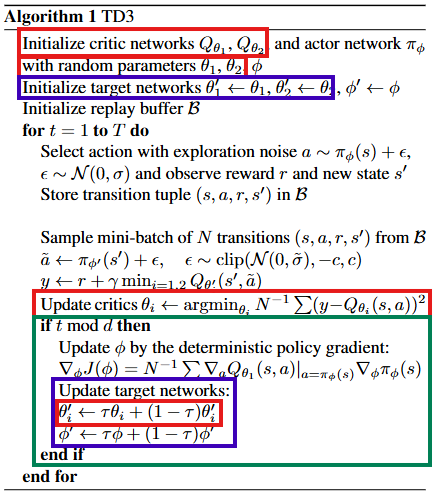

## Library imports

In [1]:
import gymnasium as gym
import torch
from torch import nn
import torch.optim as optim
from torch.distributions import Normal      # normal dist

import numpy as np
import matplotlib.pyplot as plt
from statistics import mean, stdev
import random

import re, os, json, time
from datetime import datetime
from collections import deque
from tqdm import tqdm

## Parameter and Class Definition

In [2]:
class Actor(nn.Module):
    def __init__(self, obs_dim: int,
                 act_dim: int,
                 act_low, act_high, 
                 hidden_layers=[64,64], 
                 cuda_enabled=False):
        ''' Initialize the model and create a list of layers '''
        super().__init__()

        self.act_low, self.act_high = act_low, act_high

        self.layers = nn.ModuleList()
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        # hidden layers
        for layer_size in hidden_layers:
            self.layers.append(nn.Linear(obs_dim, layer_size))
            obs_dim = layer_size
        # output layers
        self.layers.append(nn.Linear(obs_dim, self.act_dim))
        self.tanh = nn.Tanh()

        if cuda_enabled: self.cuda()

    def forward(self, input):
        for layer in self.layers[:-1]:
            input = torch.relu(layer(input))
        output = self.layers[-1](input)
        act_tanh = self.tanh(output)

        # rescale to environment bounds
        act = 0.5 * (act_tanh + 1.0) * (self.act_high - self.act_low) + self.act_low
        return act
    
class Critic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_layers=[32,32], cuda_enabled=False):
        ''' Initialize the model and create a list of layers '''
        super().__init__()

        self.layers = nn.ModuleList()
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        
        prev_layer_size = hidden_layers[0]
        self.layers.append(nn.Linear(obs_dim+act_dim,prev_layer_size))
        for layer_size in hidden_layers[1:]:
            self.layers.append(nn.Linear(prev_layer_size, layer_size))
            prev_layer_size = layer_size

        self.layers.append(nn.Linear(prev_layer_size, self.act_dim))
        if cuda_enabled: self.cuda()

    def forward(self, obs, act):
        ''' Return the action value estimates 
        
        Parameters:
        ------------
        obs : [batch_size, obs_dim]
        act : [batch_size, act_dim]
        '''
        input = torch.cat([obs, act], dim=-1)
        for layer in self.layers[:-1]:
            input = torch.relu(layer(input))
        output = self.layers[-1](input)
        return output

In [35]:
class TD3():
    def __init__(self,
            model_name,
            model_registry,
            env: gym.Env,
            alpha1: float,      # lr of critic 1 
            alpha2: float,      # lr of critic 2
            beta: float,        # lr of actor
            gamma: float,       # reward discount factor
            tau_c: float,       # Polyak coeff to update target critics
            tau_a: float,       # Polyak coeff to update target actor
            sigma: float,       # standard dev of Gaussian noise added to action
            clip: float,        # noise clipping for policy smoothing
            buffer_size: int,   # total number of samples in the training buffer
            buffer_init: int,   # number of prefilled samples before training
            batch_size: int,    # number of samples used in each current critic update
            update_f: int,      # update frequency of online actor + offline target networks
            iter: int,          # number of training iterations
            train_crit = dict(pass_limit=5, pass_score=975),
            result_folder: str = 'invpend_TD3_results',

            seed: int = 42,
            cuda_enabled: bool = False
        ):

        # --- hyperparameters
        self.alpha1, self.alpha2, self.beta = alpha1, alpha2, beta
        self.gamma = gamma
        self.tau_c, self.tau_a = tau_c, tau_a
        self.sigma = sigma
        self.clip = clip

        self.buffer_size, self.buffer_init, self.batch_size = buffer_size, buffer_init, batch_size
        self.update_f = update_f
        self.train_iter = iter
        self.pass_limit = train_crit['pass_limit']
        self.pass_score = train_crit['pass_score']
        self.result_folder = result_folder

        self.seed = seed
        self.cuda_enabled = cuda_enabled
        self.device = 'cuda' if (self.cuda_enabled and torch.cuda.is_available()) else 'cpu'

        # --- environments
        # self.env = gym.make("InvertedPendulum-v5", render_mode="rgb_array")
        # self.env_val = gym.make("InvertedPendulum-v5", render_mode="rgb_array")
        self.env = env
        self.obs_space = self.env.observation_space.shape[0]
        self.act_space = self.env.action_space.shape[0]
        self.act_low = torch.as_tensor(self.env.action_space.low, dtype=torch.float32, device = self.device)
        self.act_high = torch.as_tensor(self.env.action_space.high, dtype=torch.float32, device = self.device)
        
        # --- configs
        self.model_name = model_name
        match = re.search(r'v\d+', self.model_name)
        self.model_id = match.group(0) if match else 404

        self.actor_config = model_registry[self.model_name]['actor_config']
        self.critic_config = model_registry[self.model_name]['critic_config']
        
        # --- networks (2 critics + 1 actor)
        self.critic1 = Critic(self.obs_space, self.act_space, self.critic_config).to(self.device)
        self.critic1.apply(self.init_weights)
        self.critic1_optim = optim.Adam(self.critic1.parameters(), lr=self.alpha1)

        self.critic2 = Critic(self.obs_space, self.act_space, self.critic_config).to(self.device)
        self.critic2.apply(self.init_weights)
        self.critic2_optim = optim.Adam(self.critic2.parameters(), lr=self.alpha2)

        self.actor = Actor(self.obs_space, self.act_space, self.act_low, self.act_high, self.actor_config).to(self.device)
        self.actor.apply(self.init_weights)
        self.actor_optim = optim.Adam(self.actor.parameters(), lr = self.beta)
        
        # --- target networks (2 critics + 1 actor)
        self.critic1_target = Critic(self.obs_space, self.act_space, self.critic_config).to(self.device)
        self.critic1_target.load_state_dict(self.critic1.state_dict())
        self.critic1_target.eval()       # only for inference

        self.critic2_target = Critic(self.obs_space, self.act_space, self.critic_config).to(self.device)
        self.critic2_target.load_state_dict(self.critic2.state_dict())
        self.critic2_target.eval()

        self.actor_target = Actor(self.obs_space, self.act_space, self.act_low, self.act_high, self.actor_config).to(self.device)
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_target.eval()

        self.best_model_eps = 0

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0.01)

    def to_tensor(self,x):
        return torch.as_tensor(x, dtype=torch.float32, device=self.device)      

    def to_batch(self,xs):
        return torch.as_tensor(np.asarray(xs), dtype=torch.float32, device=self.device)
    
    def EMA_filter(self, reward: list, alpha):
        ''' Function that runs an exponential moving average filter along a datastream '''
        output = np.zeros(len(reward)+1)
        output[0] = reward[0]
        for idx, item in enumerate(reward):
            output[idx+1] = (1 - alpha) * output[idx] + alpha * item
        
        return output

    def plot_reward_hist(self, history, alpha = 0.1):
        ''' Function that plots the reward and filtered reward per episode, then saves the plot in a specified save directory'''
        n_episodes= len(history)
        episodes = range(n_episodes)
        filtered_reward_hist = self.EMA_filter(history, alpha)

        device_info = str(self.device) + "_"
        lr_args = fr"{self.model_id} | $\alpha_1$={self.alpha1} | $\alpha_2$={self.alpha2} | $\beta$={self.beta} | $\gamma$={self.gamma} | "
        polyak_args = fr"$\tau_c$={self.tau_c} | $\tau_a$={self.tau_a} | "
        buffer_args = fr"$n_{{buff}}$={self.buffer_size} | $n_{{i}}$={self.buffer_init} | "
        misc_args = fr"$f_{{update}}$={self.update_f} | {self.train_iter} iter"
        title = lr_args + polyak_args + buffer_args + misc_args

        plt.figure(figsize=(20,6))
        plt.plot(episodes, history[:n_episodes], color = "blue")
        plt.plot(episodes, filtered_reward_hist[:n_episodes], color = "red")
        # plt.title(f'Total reward per episode - {self.hyperparam_config}')
        plt.xlabel('Episode')
        plt.ylabel('Reward')
        plt.title(title)
        plt.legend(['Reward','Filtered episode length'])

        plt.tight_layout()
        if hasattr(self, 'save_path'):
            plt.savefig(os.path.join(self.save_path,'reward_history.png'))
        plt.show()

    def prefill_buffer(self):
        ''' Method to create and prefill the buffer with random actions prior to training '''
        # --- initialize the buffer
        self.buffer = deque(maxlen=self.buffer_size)
        obs,_ = self.env.reset()
        for _ in range(self.buffer_init):
            act = self.env.action_space.sample()
            nobs, rew, term, trunc, _ = self.env.step(act)
            done = term or trunc
            
            self.buffer.append((obs,act,rew,nobs,done))
            obs = nobs if not done else self.env.reset()[0]

    def act(self, obs,
            clip: bool = False,
            train: bool = True,
            debug: bool = False):
        ''' Method to generate a deterministic action with some Gaussian noise for stochasticity 
        This function handles both the action with unclipped Gaussian noise a~pi(s) and clipped Gaussian noise a~pi'(s')
            If the clip argument is False, use the current (online) actor network to return the action pi_theta(s)
            else use the offline actor network for pi_theta'(s')

        Parameters:
        ------------
        obs: tensor or numpy array 
            either the current or next observation. Make sure clip is true when passing nobs in for a <- pi_theta'(s')
        clip: bool
            if true, use clipped Gaussian noise
        train: bool
            flag to add noise during training but not during testing
        debug: bool
            return additional info during debug (determinisitic action, noise added, noise probability)
        

        Returns:
        ------------
        act: 1-element vector of actions
            a rescaled tanh output action (scaled to the bounds of the InvertedPendulum-v5 environment)
            the deterministic action is slightly randomized with a small added Gaussian noise 
        '''
        # --- deterministic action
        with torch.no_grad():
            if not clip:    # pi_theta(s)
                act_det = self.actor(obs)
            else:           # pi_theta'(s')
                act_det = self.actor_target(obs)

        # --- external stochasticity (Gaussian noise and clipping)
            noise = self.to_tensor(0)
            if train and self.sigma > 0.0:
                noise = self.sigma * torch.randn_like(act_det)
            
                if clip:    # clip the added Gaussian noise in policy smoothing regularization
                    noise = torch.clamp(noise, -self.clip, self.clip)
            act = act_det + noise

        # --- action clipping (env bounds)
        act = torch.clamp(act, self.actor.act_low, self.actor.act_high)

        noise_logp = Normal(loc=0.0, scale=self.sigma).log_prob(noise)
        if debug:
            return act, act_det, noise, torch.exp(noise_logp)
        
        return act.cpu().numpy()
    
    def debug(self):
        ''' Function to test the Gaussian noise injection into action '''
        
        for _ in range(100):
            obs, _ = self.env.reset()
            done = False
            while not done:

                obs_tensor = torch.tensor(obs, dtype = torch.float32, device=self.device)
                act, act_det, noise, noise_prob= self.act(obs_tensor,clip=True, debug=True)
                print(f"act_det: {act_det}, act: {act}, noise: {noise} @ {noise_prob.item():.4f}%")
                nobs, rew, term, trunc, _ = self.env.step(act)
                done = term or trunc
                obs = nobs if not done else self.env.reset()

    def soft_update(self, 
                    source: nn.Module, 
                    target: nn.Module,
                    tau: float):
        ''' Polyak update 
        
        Parameters:
        ------------
        source: nn.Module
            the online network
        target: nn.Module
            the target network whose parameters are softly updated toward the online network
        tau: float
            the Polyak coefficient (either the actor or critic tau)
        '''
        with torch.no_grad():
            for p, tp in zip(source.parameters(), target.parameters()):
                tp.data.mul_(1-tau).add_(tau * p.data)

    def eval_policy(self, env: gym.Env, n_iter_eval: int = 100, verbose:bool = False):
        ''' Assess the average reward when following the policy net in a test environment with random state initialization
        
        Parameters:
        ----------
        env : gymnasium environment
            this environment can be either the self.env_test or self.env_val environment
        n_episode_eval : int 
            the number of evaluation episodes
        verbose : bool
            whether to print testing information (should be True only during testing)

        Return:
        ----------
        average_reward : float
            the average reward received from running the test
        '''
        reward_history = []
        with torch.no_grad():
            for i in range(n_iter_eval):
                obs,_ = env.reset()
                done = False
                eps_reward = 0
                
                while not done:
                    obs_tensor = self.to_tensor(obs)
                    act = self.act(obs_tensor, train=False)
                    nobs, rew, term, trunc, _ = env.step(act)

                    eps_reward += rew

                    obs = nobs
                    done = term or trunc
                
                reward_history.append(eps_reward)
                if verbose:
                    print(f"Validation episode {i+1:3d}/{n_iter_eval}   |   Reward = {eps_reward:5.0f}", end="file=\r")
        reward_mean = mean(reward_history)
        reward_stdev = stdev(reward_history)

        return reward_mean, reward_stdev
    
    def create_directory(self):
        ''' Function that creates directory to save model state_dict, architecture, training configuration, and history
        
        Returns
        ------------
        name_codified : str
            the shortened name for the current experiment 
        hyperparameters_codified : str
            the shortened string of hyperparameter configuration
        OUTPUT_DIR : path
            the directory to which the training results and model (state_dict and architecture) will be saved
        '''
        timestamp = datetime.now().strftime("%y%m%d_%H%M")

        BASE_DIR = os.getcwd()
        RESULT_DIR = os.path.join(BASE_DIR, self.result_folder)
        os.makedirs(RESULT_DIR, exist_ok=True)      # Create the directory if one does not already exist

        # --- find trial # of the latest run
        existing_runs = [d for d in os.listdir(RESULT_DIR) if os.path.isdir(os.path.join(RESULT_DIR,d))]
        run_numbers = [int(re.search(r'run_(\d{5})',d).group(1)) for d in existing_runs if re.match(r'run_\d{5}',d)]
        trial_number = max(run_numbers,default=-1)+1

        # --- create a folder for the run
        name_codified = f"run_{trial_number:05d}"
        OUTPUT_DIR = os.path.join(RESULT_DIR,name_codified)
        os.makedirs(OUTPUT_DIR, exist_ok=True)      # Create the directory

        # --- append the mapping from run # to hyperparameter configuration in a JSON file inside RESULT_DIR
        trial_to_param_path = os.path.join(RESULT_DIR,'trial_to_param.json')
        if os.path.exists(trial_to_param_path):
            with open(trial_to_param_path, "r") as f:
                data = json.load(f)
        else:
            data = {name_codified: ""}

        device_info = str(self.device) + "_"
        lr_args = f"{self.model_id}_{self.alpha1}_{self.alpha2}_{self.beta}_{self.gamma}_"
        polyak_args = f"{self.tau_c}_{self.tau_a}_"
        buffer_args = f"{self.buffer_size}_{self.buffer_init}_"
        misc_args = f"{self.update_f}_{self.train_iter}"

        hyperparam_codified = "TD3_"+ device_info + lr_args + polyak_args + buffer_args + misc_args
        hyperparam_codified_time = f"{timestamp}_" + hyperparam_codified

        data[name_codified] = hyperparam_codified_time

        with open(trial_to_param_path, "w") as f:
            json.dump(data, f, indent=2)

        # --- store detailed hyperparameters in run folder
        training_params = {
            'device':               str(self.device),
            'device_name':          torch.cuda.get_device_name(torch.cuda.current_device()),
            'model_name':           self.model_name,
            'alpha1':               self.alpha1,
            'alpha2':               self.alpha2,
            'beta':                 self.beta,
            'gamma':                self.gamma,
            'tau_c':                self.tau_c,
            'tau_a':                self.tau_a,
            'buffer_size':          self.buffer_size,
            'buffer_init':          self.buffer_init,
            'update_f':             self.update_f,
            'train_iter':           self.train_iter,
            'seed':                 self.seed
        }

        # Store training parameters in each run 
        param_path = os.path.join(OUTPUT_DIR, "param_config.json")
        with open(param_path, "w") as f:
            json.dump({"parameters": training_params}, f, indent=2)

        return name_codified, hyperparam_codified, OUTPUT_DIR
    
    def save_model(self):
        ''' Function to save the model and optimizer state_dict for inference or continued training '''
        self.model_path = os.path.join(self.save_path, 'q_network_checkpoint.pth')
        torch.save({
            'model_state_dict': self.actor.state_dict(),
            'optimizer_state_dict': self.actor_optim.state_dict(),
        }, self.model_path)

    def train(self):
        # --- create directory to store results
        self.run_num, self.hyperparam_config, self.save_path = self.create_directory()

        # --- prefill the replay buffer prior to training
        self.prefill_buffer()

        step = 0                        # counter to update online actor + offline networks
        eps_step_count = 0              # episode length counter
        eps = 0                         # episode index
        
        self.reward_hist = [0]          # monitor reward of episodes
        self.val_hist = {}
        self.eps_hist = []              # monitor length of episdes

        pass_count = 0
        best_reward = 0

        # --- train
        # while train_term == False:        # train until convergence
        obs, _ = self.env.reset(seed=self.seed)
        # random.seed(self.seed)
        msg = "Training ended with no good model found :<"

        for i in tqdm(range(self.train_iter), ncols=100, colour="#2E6F40", desc=self.run_num):                  # train for a fix number of steps
            # --- take a step and store transition in bufer
            act = self.act(self.to_tensor(obs))
            nobs, rew, term, trunc, _ = self.env.step(act)
            done = term or trunc
            step += 1

            self.buffer.append((obs, act, rew, nobs, done))
            
            if not done:
                obs = nobs
                eps_step_count += 1
                self.reward_hist[eps] += rew                # accumulate episode reward
            else:
                obs = self.env.reset()[0]
                self.reward_hist[eps] += rew
                self.reward_hist.append(0)
                self.eps_hist.append(eps_step_count)
            
                # reset/advance
                eps_step_count = 0
                eps += 1  

            # --- policy evaluation at high eps_step_count
            if self.reward_hist[eps] >= self.pass_score:

                # TODO - time the evaluation process
                eval_reward, eval_stdev = self.eval_policy(self.env, 20, verbose = False)

                self.val_hist[eps] = f"{self.reward_hist[eps]:5.3f}, {eval_reward:5.3f}"
                if eval_reward >= best_reward:
                    best_reward = eval_reward
                    self.save_model()
                    self.best_model_eps = eps
                    msg = f"Training terminated due to episode limit, best model saved at episode {self.best_model_eps:5d} with evaluate reward {eval_reward}"
                if eval_reward > self.pass_score:
                    pass_count += 1
                else:
                    pass_count = 0

            # --- early termination if multiple consecutive eps pass
            if pass_count >= self.pass_limit:
                self.save_model()
                self.best_model_eps = eps
                msg = f"done early at episode {self.best_model_eps:5d}, desired performance reached"
                break
            

            # --- sample mini batch to train online critics
            if len(self.buffer) >= self.batch_size:
                batch = random.sample(self.buffer, self.batch_size)
                obss, acts, rews, nobss, dones = zip(*batch)

                obss = self.to_batch(obss)                      # [B, obs_space]
                acts = self.to_batch(acts)                      # [B, act_space]
                rews = self.to_batch(rews).unsqueeze(1)         # [B, 1]
                nobss = self.to_batch(nobss)                    # [B, obs_space]
                dones = self.to_batch(dones).unsqueeze(1)       # [B, 1]

                # find the TD targets using the offline actor and critics
                with torch.no_grad():
                    # target actions using the offline target actor + clipped Gaussian noise
                    target_acts = self.act(nobss, clip=True)
                    target_acts = self.to_batch(target_acts)

                    # action value estimates of the two target critics
                    target_q1 = self.critic1_target(nobss, target_acts)     # [B, 1]
                    target_q2 = self.critic2_target(nobss, target_acts)     # [B, 1]
                    target_q = torch.min(target_q1,target_q2)               # [B, 1]

                    # target
                    targets = rews + self.gamma * target_q * (1.0 - dones)

                q1 = self.critic1(obss,acts)
                q2 = self.critic2(obss,acts)

                loss_q1 = nn.MSELoss()(q1, targets)
                loss_q2 = nn.MSELoss()(q2, targets)

                self.critic1_optim.zero_grad(); loss_q1.backward(); self.critic1_optim.step()
                self.critic2_optim.zero_grad(); loss_q2.backward(); self.critic2_optim.step()

            # --- train online actor, offline critics, and offline actor
            if step % self.update_f == 0:
                # online actor update -E[Q1(s, π(s))]
                a = self.actor(obss)
                loss_actor = -self.critic1(obss, a).mean()  

                self.actor_optim.zero_grad()
                loss_actor.backward()
                self.actor_optim.step()

                # offline critic soft update
                with torch.no_grad():
                    self.soft_update(self.critic1, self.critic1_target, self.tau_c)
                    self.soft_update(self.critic2, self.critic2_target, self.tau_c)
                    self.soft_update(self.actor, self.actor_target, self.tau_a)

        print(msg)
        print(f'Best model episode {self.best_model_eps}')
        self.plot_reward_hist(self.reward_hist)
         

In [27]:
def set_global_seed(env: gym.Env, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    env.action_space.seed(seed)

In [36]:
model_registry = {
    'TD3_v0': {
        'actor_config': [64,64],
        'critic_config': [64,64]
    }
}

MODEL_NAME = 'TD3_v0'
ALPHA1 = 5e-3
ALPHA2 = 5e-3
BETA = 5e-3
GAMMA = 0.99
TAU_C = 5e-2
TAU_A = 5e-2
SIGMA = 0.2
CLIP = 0.5

BUFFER_SIZE = 10000
BUFFER_INIT = 1000
BATCH_SIZE = 64

UPDATE_FREQ = 2
TRAIN_ITER = 100000
TRAIN_CRIT = {'pass_limit':10, 'pass_score':9000}
RESULT_FOLDER = 'invdoublepend_TD3_results'


In [37]:
torch.device('cuda')

device(type='cuda')

## TD3 training

run_00010: 100%|███████████████████████████████████████████| 100000/100000 [11:12<00:00, 148.76it/s]


Training terminated due to episode limit, best model saved at episode   299 with evaluate reward 9359.345855316275
Best model episode 299


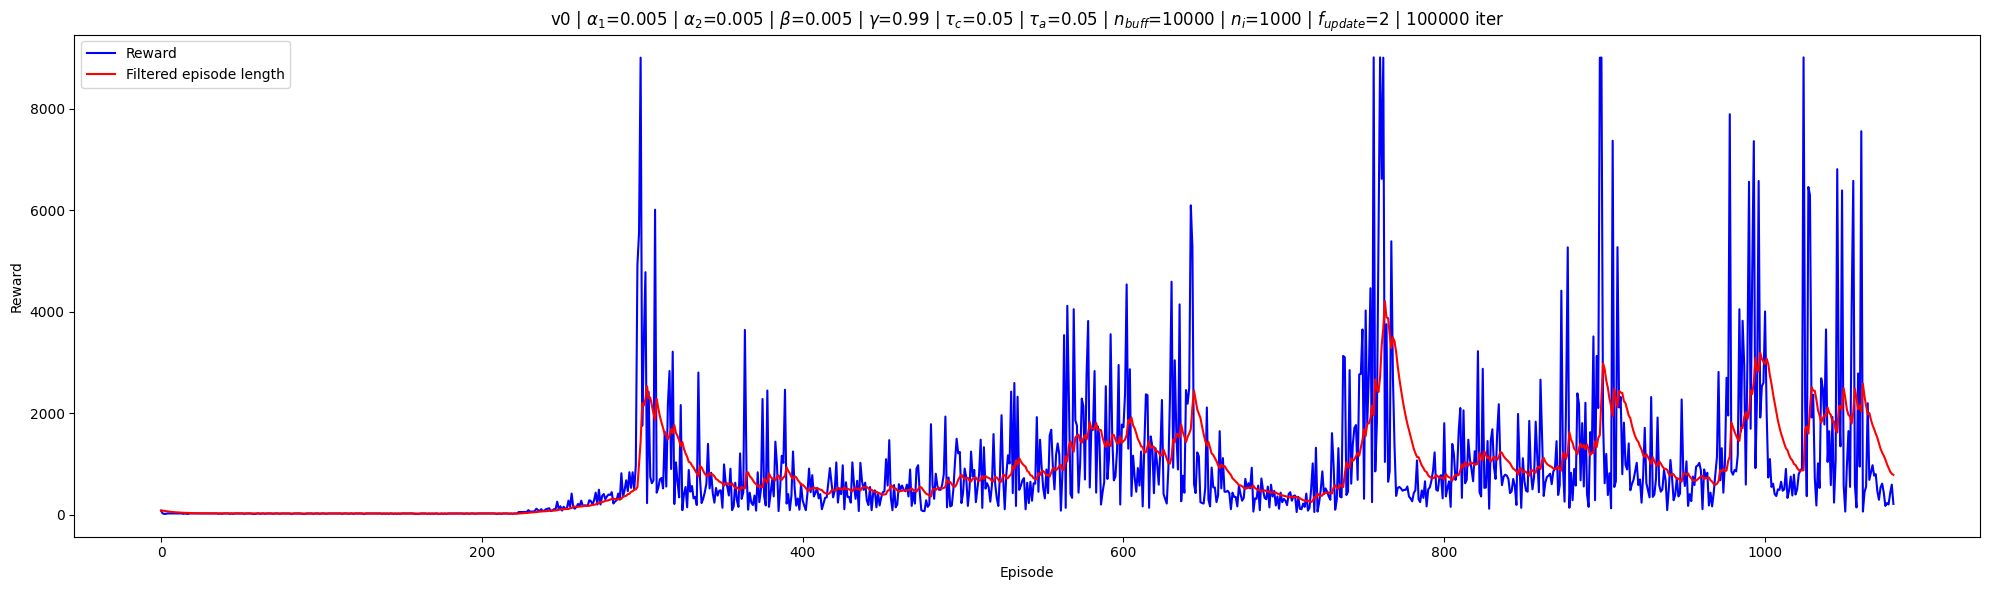

In [39]:
env = gym.make("InvertedDoublePendulum-v5")
# for i in range(1):
#     seed = np.random.randint(1,100)
#     seed = 94
#     # set_global_seed(env,seed=seed)
seed = 94
  
TD3_experiment = TD3(model_name=MODEL_NAME, model_registry=model_registry, env=env,
                alpha1=ALPHA1,alpha2=ALPHA2,beta=BETA,gamma=GAMMA,
                tau_c=TAU_C,tau_a=TAU_A,sigma=SIGMA,clip=CLIP,
                buffer_size=BUFFER_SIZE,buffer_init=BUFFER_INIT,
                batch_size=BATCH_SIZE, update_f=UPDATE_FREQ, iter=TRAIN_ITER,
                train_crit=TRAIN_CRIT,
                result_folder=RESULT_FOLDER,
                cuda_enabled=False,
                seed=seed)
            
TD3_experiment.train()